# Basin Data Preprocessing with Improved Normalization Strategy 1: Log-Transform Before Area Normalization

**Date: 2025-01-18**

**Strategy 1: Log-Transform Before Area Normalization**

This section implements the recommended approach to address numerical instability issues identified in the previous normalization strategy. Instead of directly normalizing discharge by basin area (which can create extreme values), we:

1. **First apply log transformation** to discharge to compress the range and stabilize values
2. **Then normalize by (scaled) basin area** to account for basin size differences  
3. **Apply global z-score normalization** for consistent scaling across all variables

**Key Benefits:**
- **Numerical Stability**: Log transformation prevents extreme values from discharge/area normalization
- **Preserved Relationships**: Maintains the relative relationships between discharge and basin characteristics
- **Better Model Performance**: More stable input features for LSTM training
- **Reduced Variance**: Compressed value ranges reduce the risk of gradient explosion/vanishing

**Normalization Order:**
1. Log-transform discharge: `log(discharge + ε)`
2. Area normalization: `log_discharge / (basin_area / scale_factor)`  
3. Global z-score: `(value - global_mean) / global_std`

This approach addresses the extreme values identified in the distribution analysis and provides a more robust preprocessing pipeline for hydrological modeling.

In [54]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Configuration for Strategy 1: Log-Transform Before Area Normalization ---
ATTRIBUTES_FILE_S1 = '../metadata/attributes.csv'
INPUT_CSV_DIR_S1 = '../metadata/csv_filtered'
OUTPUT_NC_DIR_S1 = '../data/time_series'  # New output directory for this strategy

# Ensure output directory exists
os.makedirs(OUTPUT_NC_DIR_S1, exist_ok=True)

# Variables to log transform BEFORE area normalization (key difference)
LOG_TRANSFORM_VARS_S1 = ['discharge', 'prcp', 'swe']
EPSILON_S1 = 1e-6  # Small constant to avoid log(0)
BASIN_AREA_SCALE_DIVISOR_S1 = 1000.0  # Factor to divide basin_area by

# Variables to normalize globally (after log+area normalization for discharge)
# Note: 'discharge' here will be log-transformed THEN area-normalized
NORMALIZE_VARS_S1 = ['discharge', 'dayl', 'prcp', 'srad', 'swe', 'tmax', 'tmin', 'vp']

print("Configuration for Strategy 1: Log-Transform Before Area Normalization")
print(f"Input CSV Directory: {INPUT_CSV_DIR_S1}")
print(f"Output NetCDF Directory: {OUTPUT_NC_DIR_S1}")
print(f"Basin Area Scale Divisor: {BASIN_AREA_SCALE_DIVISOR_S1}")
print(f"Variables for log transformation: {LOG_TRANSFORM_VARS_S1}")
print(f"Variables for global normalization: {NORMALIZE_VARS_S1}")
print(f"Epsilon for log transform: {EPSILON_S1}")

Configuration for Strategy 1: Log-Transform Before Area Normalization
Input CSV Directory: ../metadata/csv_filtered
Output NetCDF Directory: ../data/time_series
Basin Area Scale Divisor: 1000.0
Variables for log transformation: ['discharge', 'prcp', 'swe']
Variables for global normalization: ['discharge', 'dayl', 'prcp', 'srad', 'swe', 'tmax', 'tmin', 'vp']
Epsilon for log transform: 1e-06


In [55]:
# --- 1. Load attributes for Strategy 1 ---
try:
    attributes_df_s1 = pd.read_csv(ATTRIBUTES_FILE_S1)
    # Use gauge_id as index for easy lookup
    attributes_df_s1.set_index('gauge_id', inplace=True)
    print(f"Successfully loaded attributes from '{ATTRIBUTES_FILE_S1}'")
    print(f"Number of basins in attributes: {len(attributes_df_s1)}")
except FileNotFoundError:
    print(f"Error: Attributes file '{ATTRIBUTES_FILE_S1}' not found. Please check the path.")
except KeyError:
    print(f"Error: 'gauge_id' column not found in '{ATTRIBUTES_FILE_S1}'.")

Successfully loaded attributes from '../metadata/attributes.csv'
Number of basins in attributes: 1088


In [56]:
# --- 2. Strategy 1: Log-Transform THEN Area Normalize ---
import warnings

basin_csv_files_s1 = glob.glob(os.path.join(INPUT_CSV_DIR_S1, "*.csv"))
if not basin_csv_files_s1:
    print(f"Error: No CSV files found in '{INPUT_CSV_DIR_S1}'. Please check the path.")

all_log_then_area_normalized_discharge_values = []
processed_data_for_global_norm_s1 = []  # List to store processed data

# Data for comparison plots
scatter_plot_basin_areas_s1 = []
scatter_plot_mean_original_discharges_s1 = []
scatter_plot_mean_log_discharges_s1 = []
scatter_plot_mean_log_area_norm_discharges_s1 = []

print(f"\n--- Strategy 1 Pass 1: Log-Transform BEFORE Area Normalization ---")
print("Processing order:")
print("1. Load raw discharge data")
print("2. Apply log transformation: log(discharge + ε)")  
print("3. Apply area normalization: log_discharge / (basin_area / scale_factor)")
print("4. Collect for global normalization")

warnings.filterwarnings('ignore', category=FutureWarning, message="A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.")
warnings.filterwarnings('ignore', category=RuntimeWarning, message="Mean of empty slice")

skip_count = 0

for csv_file_path in tqdm(basin_csv_files_s1):
    gauge_id_with_extension = os.path.basename(csv_file_path)
    gauge_id = gauge_id_with_extension.replace('.csv', '')

    try:
        basin_area = attributes_df_s1.loc[gauge_id, 'area']
    except KeyError:
        print(f"  Warning: gauge_id '{gauge_id}' not found in attributes.csv. Skipping this basin.")
        continue

    if pd.isna(basin_area) or basin_area <= 0:
        print(f"  Warning: Area for {gauge_id} is {basin_area}. Skipping this basin due to invalid area.")
        continue

    # Load basin time series data
    try:
        df_s1 = pd.read_csv(csv_file_path)
    except Exception as e:
        print(f"  Error loading CSV {csv_file_path}: {e}. Skipping.")
        continue

    if 'date' not in df_s1.columns:
        print(f"  Warning: 'date' column not found in {gauge_id}. Skipping.")
        continue
    
    df_s1['date'] = pd.to_datetime(df_s1['date'])

    if 'discharge' not in df_s1.columns:
        print(f"  Warning: 'discharge' column not found in {gauge_id}. Skipping.")
        continue

    # Store original discharge for comparison (only valid values for statistics)
    original_discharge = df_s1['discharge'].copy()
    mean_original_discharge = original_discharge.mean()  # This handles NaN automatically
    
    # === CRITICAL: PRESERVE TEMPORAL SEQUENCE - DO NOT DROP NaN VALUES ===
    # We need to preserve all rows to maintain temporal order for neural hydrology
    
    # === STRATEGY 1: LOG TRANSFORM FIRST (while preserving NaN) ===
    # Step 1: Apply log transformation to discharge BEFORE area normalization
    # Only transform non-NaN values, keep NaN as NaN
    discharge_mask = df_s1['discharge'].notna()
    df_s1.loc[discharge_mask, 'discharge'] = np.log(df_s1.loc[discharge_mask, 'discharge'] + EPSILON_S1)
    mean_log_discharge = df_s1['discharge'].mean()  # This handles NaN automatically
    
    # Step 2: THEN apply area normalization to the log-transformed discharge
    scaled_basin_area = basin_area / BASIN_AREA_SCALE_DIVISOR_S1
    
    if scaled_basin_area == 0:
        print(f"  Warning: Scaled basin area is 0 for {gauge_id} (original area: {basin_area}). Skipping.")
        continue
    
    # Apply area normalization only to non-NaN values
    df_s1.loc[discharge_mask, 'discharge'] = df_s1.loc[discharge_mask, 'discharge'] / scaled_basin_area
    mean_log_area_norm_discharge = df_s1['discharge'].mean()  # This handles NaN automatically
    
    # Log transform other variables as well (preserving NaN where appropriate)
    for col in LOG_TRANSFORM_VARS_S1:
        if col != 'discharge' and col in df_s1.columns:  # discharge already transformed
            if col in ['prcp', 'swe']:
                # For precipitation and snow, fill NaN with 0 before log transform (makes sense physically)
                df_s1[col].fillna(0.0, inplace=True)
            # Apply log transform only to non-NaN values
            col_mask = df_s1[col].notna()
            df_s1.loc[col_mask, col] = np.log(df_s1.loc[col_mask, col] + EPSILON_S1)

    # === CRITICAL: SPLIT INTO TRAIN/TEST TO AVOID DATA LEAKAGE ===
    # Split the data into train (1980-2012) and test (2013-2023) periods
    train_mask = df_s1['date'] <= '2012-12-31'
    test_mask = df_s1['date'] >= '2013-01-01'
    
    df_train = df_s1[train_mask].copy()
    df_test = df_s1[test_mask].copy()
    
    
    if len(df_train) == 0:
        # print(f"  Warning: No training data for {gauge_id}. Skipping.")
        skip_count += 1
        continue
    
    # Collect data for plots and analysis (using training data only, excluding NaN)
    if pd.notna(mean_original_discharge) and pd.notna(basin_area):
        scatter_plot_basin_areas_s1.append(basin_area)
        scatter_plot_mean_original_discharges_s1.append(mean_original_discharge)
        scatter_plot_mean_log_discharges_s1.append(mean_log_discharge)
        scatter_plot_mean_log_area_norm_discharges_s1.append(mean_log_area_norm_discharge)

    # Collect log-then-area-normalized discharge values for distribution analysis 
    # (only from training period and only non-NaN values)
    train_discharge_values = df_train['discharge'].dropna().tolist()
    all_log_then_area_normalized_discharge_values.extend(train_discharge_values)

    # Store both train and test data for global statistics calculation
    # IMPORTANT: Full temporal sequences are preserved with NaN values intact
    processed_data_for_global_norm_s1.append({
        'gauge_id': gauge_id, 
        'df_train': df_train.copy(),  # Contains NaN values where appropriate
        'df_test': df_test.copy() if len(df_test) > 0 else None  # Contains NaN values where appropriate
    })

print(f"\nCompleted. Processed {len(processed_data_for_global_norm_s1)} basins, skipping {skip_count} basins.")
if not processed_data_for_global_norm_s1:
    print("No basin data was successfully processed in Strategy 1.")


--- Strategy 1 Pass 1: Log-Transform BEFORE Area Normalization ---
Processing order:
1. Load raw discharge data
2. Apply log transformation: log(discharge + ε)
3. Apply area normalization: log_discharge / (basin_area / scale_factor)
4. Collect for global normalization


100%|██████████| 976/976 [00:16<00:00, 58.86it/s]


Completed. Processed 975 basins, skipping 1 basins.



--- Strategy 1: Visualization of Discharge Transformations ---


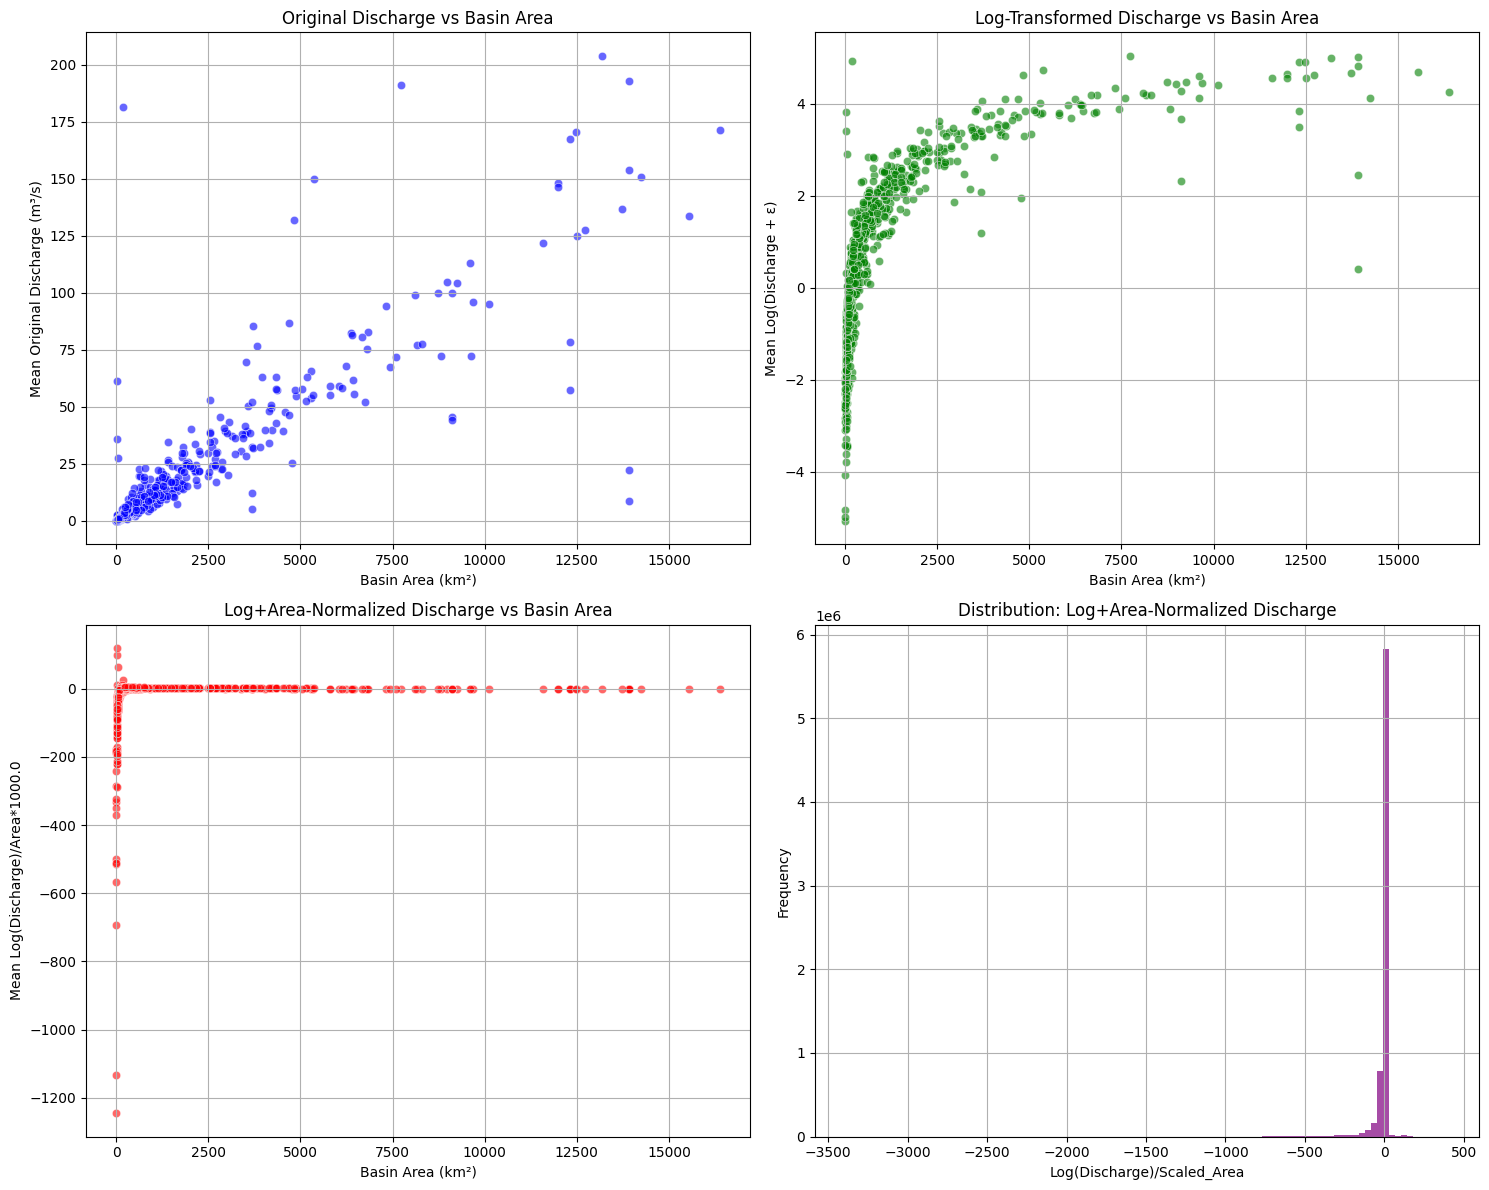


--- Strategy 1 Summary Statistics ---
Original Discharge:
count    858.000000
mean      14.153692
std       27.919092
min        0.038030
25%        1.177993
50%        3.595899
75%       12.208385
max      204.097644
dtype: float64

Log-Transformed Discharge:
count    858.000000
mean       0.761949
std        1.867305
min       -5.072236
25%       -0.578245
50%        0.724523
75%        2.080762
max        5.048043
dtype: float64

Log+Area-Normalized Discharge:
count     858.000000
mean      -17.976849
std        82.073442
min     -1245.946707
25%        -6.002181
50%         0.885216
75%         2.128483
max       119.496275
dtype: float64


In [57]:
# --- Strategy 1 Visualization: Compare Discharge Transformations ---
print(f"\n--- Strategy 1: Visualization of Discharge Transformations ---")

if (scatter_plot_basin_areas_s1 and scatter_plot_mean_original_discharges_s1 and 
    scatter_plot_mean_log_discharges_s1 and scatter_plot_mean_log_area_norm_discharges_s1):
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Original Discharge vs Basin Area
    axes[0, 0].scatter(scatter_plot_basin_areas_s1, scatter_plot_mean_original_discharges_s1, 
                      alpha=0.6, edgecolors='w', linewidth=0.5, color='blue')
    axes[0, 0].set_title('Original Discharge vs Basin Area')
    axes[0, 0].set_xlabel('Basin Area (km²)')
    axes[0, 0].set_ylabel('Mean Original Discharge (m³/s)')
    axes[0, 0].grid(True)
    
    # Plot 2: Log-Transformed Discharge vs Basin Area  
    axes[0, 1].scatter(scatter_plot_basin_areas_s1, scatter_plot_mean_log_discharges_s1, 
                      alpha=0.6, edgecolors='w', linewidth=0.5, color='green')
    axes[0, 1].set_title('Log-Transformed Discharge vs Basin Area')
    axes[0, 1].set_xlabel('Basin Area (km²)')
    axes[0, 1].set_ylabel('Mean Log(Discharge + ε)')
    axes[0, 1].grid(True)
    
    # Plot 3: Log+Area-Normalized Discharge vs Basin Area
    axes[1, 0].scatter(scatter_plot_basin_areas_s1, scatter_plot_mean_log_area_norm_discharges_s1, 
                      alpha=0.6, edgecolors='w', linewidth=0.5, color='red')
    axes[1, 0].set_title('Log+Area-Normalized Discharge vs Basin Area')
    axes[1, 0].set_xlabel('Basin Area (km²)')
    axes[1, 0].set_ylabel(f'Mean Log(Discharge)/Area*{BASIN_AREA_SCALE_DIVISOR_S1}')
    axes[1, 0].grid(True)
    
    # Plot 4: Distribution of Final Normalized Discharge
    axes[1, 1].hist(all_log_then_area_normalized_discharge_values, bins=100, alpha=0.7, color='purple')
    axes[1, 1].set_title('Distribution: Log+Area-Normalized Discharge')
    axes[1, 1].set_xlabel('Log(Discharge)/Scaled_Area')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n--- Strategy 1 Summary Statistics ---")
    original_stats = pd.Series(scatter_plot_mean_original_discharges_s1)
    log_stats = pd.Series(scatter_plot_mean_log_discharges_s1)
    log_area_stats = pd.Series(scatter_plot_mean_log_area_norm_discharges_s1)
    
    print("Original Discharge:")
    print(original_stats.describe())
    print("\nLog-Transformed Discharge:")  
    print(log_stats.describe())
    print("\nLog+Area-Normalized Discharge:")
    print(log_area_stats.describe())
    
else:
    print("No data available for Strategy 1 visualizations.")

In [59]:
discharge_series = pd.Series(all_log_then_area_normalized_discharge_values)
print(discharge_series.describe())

count    7.089267e+06
mean    -1.169489e+01
std      6.784124e+01
min     -3.393650e+03
25%     -2.712180e+00
50%      9.952960e-01
75%      2.657696e+00
max      4.082621e+02
dtype: float64


In [60]:
# --- Strategy 1: Calculate Global Statistics for Z-Score Normalization (TRAIN SET ONLY) ---
print(f"\n--- Strategy 1: Calculating global statistics from TRAINING data only (1980-2012) ---")
print("🚨 CRITICAL: Using only training set to avoid data leakage!")

if not processed_data_for_global_norm_s1:
    print("No data available for global statistics calculation in Strategy 1. Exiting.")
else:
    # Combine ONLY TRAINING DataFrames to calculate global statistics
    train_dfs_s1 = []
    for basin_data in processed_data_for_global_norm_s1:
        if basin_data['df_train'] is not None and len(basin_data['df_train']) > 0:
            train_dfs_s1.append(basin_data['df_train'])
    
    if not train_dfs_s1:
        print("No training data available for global statistics calculation.")
    else:
        combined_train_df_s1 = pd.concat(train_dfs_s1, ignore_index=True)
        print(f"Combined training dataset shape: {combined_train_df_s1.shape}")
        print(f"Training period: {combined_train_df_s1['date'].min()} to {combined_train_df_s1['date'].max()}")

        global_means_s1 = {}
        global_stds_s1 = {}

        for var in NORMALIZE_VARS_S1:
            if var in combined_train_df_s1.columns:
                # Calculate statistics only from non-NaN values
                # pandas mean() and std() automatically handle NaN values
                global_means_s1[var] = combined_train_df_s1[var].mean()  # Excludes NaN
                global_stds_s1[var] = combined_train_df_s1[var].std()    # Excludes NaN
                
                # Check for valid statistics
                if pd.isna(global_means_s1[var]) or pd.isna(global_stds_s1[var]):
                    print(f"  Warning: Could not calculate valid statistics for '{var}' (all values may be NaN). Skipping normalization for this variable.")
                    continue
                    
                # Handle cases where std might be 0 (e.g., if a variable is constant)
                if global_stds_s1[var] == 0:
                    print(f"  Warning: Global standard deviation for '{var}' is 0. Using 1.0 to avoid division by zero.")
                    global_stds_s1[var] = 1.0
                
                # Count valid (non-NaN) values used for statistics
                valid_count = combined_train_df_s1[var].count()
                print(f"  Global mean for {var}: {global_means_s1[var]:.4f}, Global std: {global_stds_s1[var]:.4f} (from {valid_count} valid values)")
            else:
                print(f"  Warning: Variable '{var}' for normalization not found in combined training data. Will not be normalized.")
        
        print(f"\nGlobal statistics calculated from TRAINING SET for {len(global_means_s1)} variables.")
        print("These statistics will be applied to both training and test sets.")


--- Strategy 1: Calculating global statistics from TRAINING data only (1980-2012) ---
🚨 CRITICAL: Using only training set to avoid data leakage!
Combined training dataset shape: (11752650, 9)
Training period: 1980-01-01 00:00:00 to 2012-12-31 00:00:00
  Global mean for discharge: -11.6949, Global std: 67.8412 (from 7089267 valid values)
Training period: 1980-01-01 00:00:00 to 2012-12-31 00:00:00
  Global mean for discharge: -11.6949, Global std: 67.8412 (from 7089267 valid values)
  Global mean for dayl: 43191.3542, Global std: 8322.7121 (from 11752650 valid values)
  Global mean for prcp: -6.8471, Global std: 7.4811 (from 11752650 valid values)
  Global mean for dayl: 43191.3542, Global std: 8322.7121 (from 11752650 valid values)
  Global mean for prcp: -6.8471, Global std: 7.4811 (from 11752650 valid values)
  Global mean for srad: 297.5412, Global std: 134.1672 (from 11752650 valid values)
  Global mean for swe: -6.4978, Global std: 8.5386 (from 11752650 valid values)
  Global mean

In [63]:
# --- Final: Apply global z-score normalization to full dataset and save as NetCDF ---
from tqdm import tqdm

successful_saves_s1 = 0
failed_saves_s1 = 0

for basin_data in tqdm(processed_data_for_global_norm_s1, desc="Saving full dataset for all basins"):
    gauge_id = basin_data['gauge_id']
    df_train = basin_data['df_train']
    df_test = basin_data.get('df_test')
    # Combine train and test to reconstruct full log+area normalized series
    df_full = pd.concat([df_train, df_test] if df_test is not None else [df_train])
    df_full.sort_values('date', inplace=True)

    # Apply global z-score normalization using training-derived statistics
    for var in NORMALIZE_VARS_S1:
        if var in df_full.columns and var in global_means_s1 and var in global_stds_s1:
            valid_mask = df_full[var].notna()
            df_full.loc[valid_mask, var] = (df_full.loc[valid_mask, var] - global_means_s1[var]) / global_stds_s1[var]

    # Save the full DataFrame as NetCDF, preserving all rows and NaNs
    try:
        ds = xr.Dataset.from_dataframe(df_full.set_index('date'))
        ds.attrs['gauge_id'] = gauge_id
        ds.attrs['preprocessing_strategy'] = 'Strategy1_LogThenAreaNorm'
        output_nc = os.path.join(OUTPUT_NC_DIR_S1, f"{gauge_id}.nc")
        ds.to_netcdf(output_nc)
        successful_saves_s1 += 1
    except Exception as e:
        print(f"Failed to save NetCDF for {gauge_id}: {e}")
        failed_saves_s1 += 1

print(f"\nNetCDF save complete. Successful: {successful_saves_s1}, Failed: {failed_saves_s1}")


Saving full dataset for all basins: 100%|██████████| 975/975 [00:18<00:00, 53.94it/s]


NetCDF save complete. Successful: 975, Failed: 0
